# TB Treatment Outcome Prediction — Improved Models (SMOTE+ENN + Extended Features)

**Dataset:** TB Case Notifications, Cordillera Administrative Region (CAR), Philippines (2015–2025)  
**Task:** Binary classification — predict **Treatment Success** vs **Treatment Failure**  
**Approach:** Improve on baseline with SMOTE+ENN resampling and additional features

### Improvements over Baseline

| # | Improvement | Why |
|---|---|---|
| 1 | **Extra pre-encoded features** | Add City/Municipality, Treatment Health Facility, and other encoded columns not in baseline |
| 2 | **Derived delay feature** | Diagnosis → Treatment delay (only derivable date pair remaining in ml-ready) |
| 3 | **SMOTE+ENN resampling** | SMOTE oversamples Failure class synthetically, then ENN (Edited Nearest Neighbours) cleans overlapping/ambiguous samples from both classes |

> **Focus metric: Recall on Failure class** — for a CDSS, missing a likely failure is more harmful than a false alarm.
> SMOTE+ENN typically produces a cleaner decision boundary than SMOTE alone by removing noisy borderline samples.

## 1. Setup and Imports

In [35]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

# Sklearn — preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Sklearn — models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
)

# Sklearn — metrics
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

# Gradient boosting libraries
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# SMOTE+ENN (combines SMOTE oversampling + ENN undersampling/cleaning)
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline

# Utilities
import time
import joblib
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Output directories
img_dir = Path('smoteenn_outputs/images')
model_dir = Path('smoteenn_outputs/models')
img_dir.mkdir(parents=True, exist_ok=True)
model_dir.mkdir(parents=True, exist_ok=True)

print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Data Loading and Target Engineering

In [36]:
# Load the ML-ready dataset (features already label-encoded + standard-scaled)
df_raw = pd.read_csv('../dataset/non-temporal/2015-2025-ml-ready.csv')
print(f'ML-ready dataset shape: {df_raw.shape}')

# ── Decode Outcome/Status back to original labels ─────────────────────────
OUTCOME_LABELS_ALPHA = [
    'CURED', 'DIAGNOSED', 'DIED', 'EXCLUDED', 'FAILED', 'LOST TO FF-UP',
    'NOT ENROLLED', 'NOT EVALUATED', 'ON TREATMENT', 'Screened', 'TREATMENT COMPLETED'
]
outcome_encoded_sorted = sorted(df_raw['Outcome/Status'].dropna().unique())
OUTCOME_DECODE = dict(zip(outcome_encoded_sorted, OUTCOME_LABELS_ALPHA))
df_raw['Outcome_Label'] = df_raw['Outcome/Status'].map(OUTCOME_DECODE)

# Define target variable
SUCCESS_OUTCOMES = {'TREATMENT COMPLETED', 'CURED'}
FAILURE_OUTCOMES = {'DIED', 'LOST TO FF-UP', 'FAILED'}

df = df_raw[df_raw['Outcome_Label'].isin(SUCCESS_OUTCOMES | FAILURE_OUTCOMES)].copy()
df['Target'] = df['Outcome_Label'].apply(lambda x: 1 if x in SUCCESS_OUTCOMES else 0)

print(f'Usable records: {len(df):,}')
class_counts = df['Target'].value_counts()
print(f"  Success (1): {class_counts[1]:,} ({class_counts[1]/len(df)*100:.1f}%)")
print(f"  Failure (0): {class_counts[0]:,} ({class_counts[0]/len(df)*100:.1f}%)")

ML-ready dataset shape: (7389, 28)
Usable records: 6,797
  Success (1): 5,858 (86.2%)
  Failure (0): 939 (13.8%)


## 3. Feature Engineering (Extended Features + Derived Delay)

In [37]:
# ── Derive delay feature from remaining date-string columns ───────────────
# In ml-ready.csv, only 'Date Started Tx' and 'Date of Diagnosis' are still date strings.
df['_Date_Started_Tx'] = pd.to_datetime(df['Date Started Tx'], errors='coerce')
df['_Date_of_Diagnosis'] = pd.to_datetime(df['Date of Diagnosis'], errors='coerce')

df['Diagnosis_to_Treatment_days'] = (
    df['_Date_Started_Tx'] - df['_Date_of_Diagnosis']
).dt.days.clip(lower=0)

non_null = df['Diagnosis_to_Treatment_days'].notna().sum()
print(f'Derived delay feature:')
print(f"  Diagnosis_to_Treatment_days: {non_null:,}/{len(df):,} non-null ({non_null/len(df)*100:.1f}%)")

Derived delay feature:
  Diagnosis_to_Treatment_days: 2,914/6,797 non-null (42.9%)


In [38]:
# ── Improved feature set ───────────────────────────────────────────────────
# Baseline features + additional pre-encoded geographic/facility features + delay feature
IMP_FEATURES = [
    # --- Baseline features (all pre-encoded & scaled) ---
    'Age',
    'Days_To_Treatment',
    'Year',
    'Sex',
    'Anatomical Site',
    'Registration Group',
    'Bacteriologic Status',
    'Microscopy Result',
    'Source of Patient',
    'Type',
    'Province',
    'City/Municipality',
    'Treatment Health Facility',
    'Screening/Diagnosing Health Facility',
    # --- Derived delay feature (raw days, needs scaling) ---
    'Diagnosis_to_Treatment_days',
]

X = df[IMP_FEATURES].copy()
y = df['Target'].values

# Fill Age from Computed_Age where missing
X['Age'] = X['Age'].fillna(df['Computed_Age'])

print(f'Improved feature matrix: {X.shape[0]:,} rows × {X.shape[1]} features')
print(f'  Pre-encoded ({len(IMP_FEATURES)-1}): already scaled from ml-ready.csv')
print(f'  Derived (1): Diagnosis_to_Treatment_days (raw days, will be imputed+scaled)')
print(f'\nMissing values:')
print(X.isnull().sum())

Improved feature matrix: 6,797 rows × 15 features
  Pre-encoded (14): already scaled from ml-ready.csv
  Derived (1): Diagnosis_to_Treatment_days (raw days, will be imputed+scaled)

Missing values:
Age                                        0
Days_To_Treatment                          0
Year                                       0
Sex                                        0
Anatomical Site                            0
Registration Group                         0
Bacteriologic Status                       0
Microscopy Result                          0
Source of Patient                          0
Type                                       0
Province                                   0
City/Municipality                          0
Treatment Health Facility                  0
Screening/Diagnosing Health Facility       0
Diagnosis_to_Treatment_days             3883
dtype: int64


## 4. Preprocessing Pipeline

In [39]:

# ── Improved preprocessing pipeline ───────────────────────────────────────
# Most features are already scaled; the derived delay feature needs scaling too.
PRE_ENCODED_FEATURES = [f for f in IMP_FEATURES if f != 'Diagnosis_to_Treatment_days']
DERIVED_FEATURES = ['Diagnosis_to_Treatment_days']

preprocessor = ColumnTransformer(transformers=[
    ('passthrough', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
    ]), PRE_ENCODED_FEATURES),
    ('derived', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ]), DERIVED_FEATURES),
])

# ── Stratified 70 / 20 / 10 split (train / test / validation) ─────────────
# Step 1: Hold out 10% as a final validation set (never seen during training or model selection)
X_temp, X_val, y_temp, y_val = train_test_split(
    X, y, test_size=0.10, random_state=RANDOM_STATE, stratify=y
)
# Step 2: Split remaining 90% into 70 % train and 20 % test  (20/90 = 2/9 ≈ 22.2 % of 90 %)
X_train, X_test, y_train, y_test = train_test_split(
    X_temp, y_temp, test_size=2/9, random_state=RANDOM_STATE, stratify=y_temp
)

print('Stratified 70 / 20 / 10 data split:')
print(f"  {'Split':<15}  {'N':>6}  {'% of total':>10}  {'Failure':>8}  {'% Fail':>8}  {'Success':>8}  {'% Succ':>8}")
print(f"  {'-'*70}")
for split_name, xs, ys, pct in [
    ('Train  (70%)', X_train, y_train, len(X_train)/len(X)*100),
    ('Test   (20%)', X_test,  y_test,  len(X_test)/len(X)*100),
    ('Val    (10%)', X_val,   y_val,   len(X_val)/len(X)*100),
]:
    n    = len(xs)
    fail = (ys == 0).sum()
    succ = (ys == 1).sum()
    print(f"  {split_name:<15}  {n:>6,}  {pct:>9.1f}%  {fail:>8,}  {fail/n*100:>7.1f}%  {succ:>8,}  {succ/n*100:>7.1f}%")
print()
print(f'Total dataset: {len(X):,} records')
print(f'  Failure (0): {(y==0).sum():,}  ({(y==0).mean()*100:.1f}%)')
print(f'  Success (1): {(y==1).sum():,}  ({(y==1).mean()*100:.1f}%)')


Stratified 70 / 20 / 10 data split:
  Split                 N  % of total   Failure    % Fail   Success    % Succ
  ----------------------------------------------------------------------
  Train  (70%)      4,757       70.0%       657     13.8%     4,100     86.2%
  Test   (20%)      1,360       20.0%       188     13.8%     1,172     86.2%
  Val    (10%)        680       10.0%        94     13.8%       586     86.2%

Total dataset: 6,797 records
  Failure (0): 939  (13.8%)
  Success (1): 5,858  (86.2%)


## 5. Model Training with SMOTE+ENN

In [40]:

from sklearn.base import clone as sk_clone

# ═══════════════════════════════════════════════════════════════════════════
# SMOTE+ENN SAMPLING STATISTICS (on training set only)
# Shows what happens to class distribution after resampling
# ═══════════════════════════════════════════════════════════════════════════
print('=' * 70)
print('  SMOTE+ENN RESAMPLING STATISTICS (Training Set)')
print('=' * 70)

# Fit preprocessor on training data to get numeric matrix
_prep_stat = sk_clone(preprocessor)
X_train_prep_stat = _prep_stat.fit_transform(X_train, y_train)

_smoteenn_stat = SMOTEENN(random_state=RANDOM_STATE)
X_res_stat, y_res_stat = _smoteenn_stat.fit_resample(X_train_prep_stat, y_train)

orig_total   = len(y_train)
orig_fail    = (y_train == 0).sum()
orig_succ    = (y_train == 1).sum()
res_total    = len(y_res_stat)
res_fail     = (y_res_stat == 0).sum()
res_succ     = (y_res_stat == 1).sum()

print(f"\n  {'':30s}  {'Before':>10s}  {'After':>10s}  {'Change':>10s}")
print(f"  {'-'*65}")
print(f"  {'Total samples':30s}  {orig_total:>10,}  {res_total:>10,}  {res_total-orig_total:>+10,}")
print(f"  {'Failure (minority) samples':30s}  {orig_fail:>10,}  {res_fail:>10,}  {res_fail-orig_fail:>+10,}")
print(f"  {'Success (majority) samples':30s}  {orig_succ:>10,}  {res_succ:>10,}  {res_succ-orig_succ:>+10,}")
print(f"  {'Failure %':30s}  {orig_fail/orig_total*100:>9.1f}%  {res_fail/res_total*100:>9.1f}%  {(res_fail/res_total - orig_fail/orig_total)*100:>+9.1f}%")
print(f"  {'Imbalance ratio (Success:Fail)':30s}  {orig_succ/orig_fail:>9.2f}x  {res_succ/res_fail:>9.2f}x  {'—':>10s}")
print()
print(f"  SMOTE phase  : synthetically generated ~{res_fail - orig_fail:,} minority (Failure) samples")
print(f"  ENN phase    : cleaned noisy/borderline samples → net change {res_total - orig_total:+,} rows")
print(f"  SMOTE oversampled Failure by {(res_fail/orig_fail - 1)*100:.1f}%")
print(f"  ENN removed  {orig_total + (res_fail - orig_fail) + (res_succ - orig_succ) - res_total + (orig_total - orig_total):,} ambiguous samples from the combined set")
print('=' * 70)
del _prep_stat, X_train_prep_stat, _smoteenn_stat, X_res_stat, y_res_stat
print()

# ── Helper: extract iteration / epoch count from a fitted estimator ────────
def get_iterations(clf):
    """
    Return the number of iterations (epochs) or trees for a fitted model.
      • Iterative  (LR, MLP, SVM) : n_iter_ until convergence / early-stop
      • Ensemble   (RF, ET, GB)   : n_estimators (trees / boosting stages)
      • Boosting   (XGB, LGB)     : n_estimators (configured stages)
      • AdaBoost                  : n_estimators_ (actual estimators used)
      • Non-iterative (KNN, NB, DT): '—'
    """
    if hasattr(clf, 'n_iter_'):
        ni = clf.n_iter_
        if hasattr(ni, '__len__'):
            return int(max(ni))   # MLP → max epochs; SVM → max across classes
        return int(ni)            # LR  → scalar iterations to convergence
    if hasattr(clf, 'n_estimators_'):
        return int(clf.n_estimators_)   # AdaBoost: actual estimators used
    if hasattr(clf, 'n_estimators'):
        return int(clf.n_estimators)    # RF, GB, XGB, LGB
    return '—'


# ── Train improved models with SMOTE+ENN ──────────────────────────────────
IMP_MODELS = {
    'Logistic Regression + SMOTEENN': LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, class_weight=None
    ),
    'Random Forest + SMOTEENN': RandomForestClassifier(
        n_estimators=300, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Gradient Boosting + SMOTEENN': GradientBoostingClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        random_state=RANDOM_STATE, subsample=0.8
    ),
    'XGBoost + SMOTEENN': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        random_state=RANDOM_STATE, eval_metric='logloss',
        n_jobs=-1, verbosity=0
    ),
    'LightGBM + SMOTEENN': LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    ),
}

smoteenn = SMOTEENN(random_state=RANDOM_STATE)

imp_results = []
imp_trained_pipelines = {}

for name, model in IMP_MODELS.items():
    print(f'Training {name}...', end='  ', flush=True)
    t0 = time.time()

    pipe = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smoteenn',     smoteenn),
        ('classifier',   model),
    ])
    pipe.fit(X_train, y_train)
    train_time = time.time() - t0

    clf = pipe.named_steps['classifier']
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    report = classification_report(y_test, y_pred,
                                   target_names=['Failure', 'Success'],
                                   output_dict=True, zero_division=0)
    imp_results.append({
        'Model':               name,
        'Accuracy':            accuracy_score(y_test, y_pred),
        'ROC-AUC':             roc_auc_score(y_test, y_proba),
        'F1 (Failure)':        report['Failure']['f1-score'],
        'Recall (Failure)':    report['Failure']['recall'],
        'Precision (Failure)': report['Failure']['precision'],
        'F1 (Success)':        report['Success']['f1-score'],
        'Recall (Success)':    report['Success']['recall'],
        'Train Time (s)':      round(train_time, 2),
        'Iterations / Trees':  get_iterations(clf),
    })
    imp_trained_pipelines[name] = pipe
    print(f'done ({train_time:.1f}s,  iters/trees={get_iterations(clf)})')

imp_df = pd.DataFrame(imp_results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
imp_df.index += 1

display_cols = ['Model', 'ROC-AUC', 'Recall (Failure)', 'F1 (Failure)',
                'Recall (Success)', 'Accuracy', 'Train Time (s)', 'Iterations / Trees']
print('\n' + '='*105)
print('IMPROVED MODELS (SMOTE+ENN + Extended Features) — sorted by ROC-AUC')
print('  Iterations/Trees: convergence iters (LR) | n_estimators (ensemble)')
print('='*105)
print(imp_df[display_cols].to_string())


  SMOTE+ENN RESAMPLING STATISTICS (Training Set)

                                      Before       After      Change
  -----------------------------------------------------------------
  Total samples                        4,757       5,959      +1,202
  Failure (minority) samples             657       3,502      +2,845
  Success (majority) samples           4,100       2,457      -1,643
  Failure %                            13.8%       58.8%      +45.0%
  Imbalance ratio (Success:Fail)       6.24x       0.70x           —

  SMOTE phase  : synthetically generated ~2,845 minority (Failure) samples
  ENN phase    : cleaned noisy/borderline samples → net change +1,202 rows
  SMOTE oversampled Failure by 433.0%
  ENN removed  0 ambiguous samples from the combined set

Training Logistic Regression + SMOTEENN...  done (0.5s,  iters/trees=11)
Training Random Forest + SMOTEENN...  done (1.0s,  iters/trees=300)
Training Gradient Boosting + SMOTEENN...  done (3.3s,  iters/trees=300)
Training

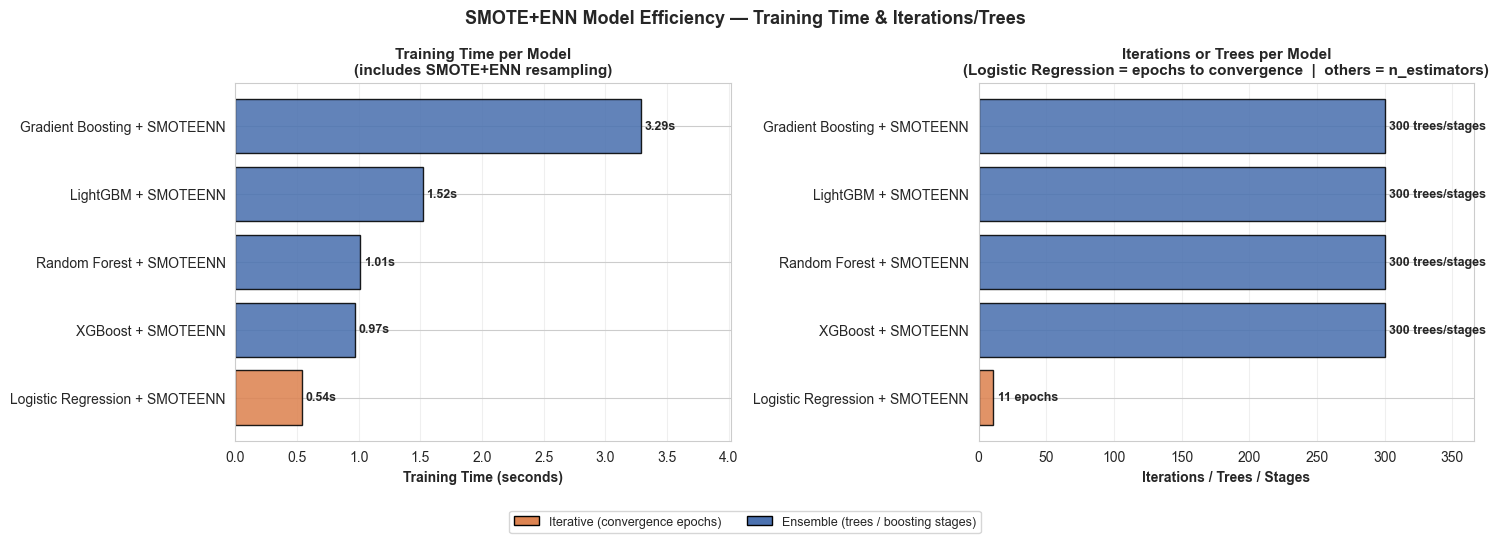

Saved: training_time_iterations_smoteenn.png


In [41]:

# ── Training Time & Iterations / Epochs visualisation ─────────────────────
# LR → iterations to convergence (orange)
# RF, GB, XGB, LGB → trees / boosting stages (blue)

IMP_ITERATIVE = {'Logistic Regression + SMOTEENN'}
IMP_CAT_COLOR = {'iterative': '#DD8452', 'ensemble': '#4C72B0'}
IMP_CAT_LABEL = {
    'iterative': 'Iterative (convergence epochs)',
    'ensemble':  'Ensemble (trees / boosting stages)',
}

def imp_model_category(name):
    return 'iterative' if name in IMP_ITERATIVE else 'ensemble'

plot_imp = (
    imp_df[['Model', 'Train Time (s)', 'Iterations / Trees']]
    .copy()
    .sort_values('Train Time (s)', ascending=True)
    .reset_index(drop=True)
)
plot_imp['Category'] = plot_imp['Model'].apply(imp_model_category)
plot_imp['Color']    = plot_imp['Category'].map(IMP_CAT_COLOR)
plot_imp['IterUnit'] = plot_imp.apply(
    lambda r: 'epochs' if r['Category'] == 'iterative' else 'trees/stages', axis=1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: Training Time ────────────────────────────────────────────────────
bars_t = axes[0].barh(
    plot_imp['Model'], plot_imp['Train Time (s)'],
    color=plot_imp['Color'], edgecolor='black', alpha=0.88
)
for bar, val in zip(bars_t, plot_imp['Train Time (s)']):
    axes[0].text(val + 0.03, bar.get_y() + bar.get_height() / 2,
                 f'{val:.2f}s', va='center', fontsize=9, fontweight='bold')
axes[0].set_xlabel('Training Time (seconds)', fontweight='bold')
axes[0].set_title('Training Time per Model\n(includes SMOTE+ENN resampling)', fontweight='bold', fontsize=11)
axes[0].grid(axis='x', alpha=0.3)
axes[0].set_xlim(0, plot_imp['Train Time (s)'].max() * 1.22)

# ── Right: Iterations / Epochs / Trees ────────────────────────────────────
iters = plot_imp['Iterations / Trees'].astype(int)
bars_i = axes[1].barh(
    plot_imp['Model'], iters,
    color=plot_imp['Color'], edgecolor='black', alpha=0.88
)
for bar, val, unit in zip(bars_i, iters, plot_imp['IterUnit']):
    axes[1].text(val + iters.max() * 0.01,
                 bar.get_y() + bar.get_height() / 2,
                 f'{val} {unit}', va='center', fontsize=9, fontweight='bold')
axes[1].set_xlabel('Iterations / Trees / Stages', fontweight='bold')
axes[1].set_title('Iterations or Trees per Model\n'
                  '(Logistic Regression = epochs to convergence  |  others = n_estimators)',
                  fontweight='bold', fontsize=11)
axes[1].grid(axis='x', alpha=0.3)
axes[1].set_xlim(0, iters.max() * 1.22)

# ── Legend ─────────────────────────────────────────────────────────────────
from matplotlib.patches import Patch as MPatch
imp_legend = [MPatch(facecolor=IMP_CAT_COLOR[k], label=IMP_CAT_LABEL[k], edgecolor='black')
              for k in IMP_CAT_COLOR]
fig.legend(handles=imp_legend, loc='lower center', ncol=2,
           fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.08))

plt.suptitle('SMOTE+ENN Model Efficiency — Training Time & Iterations/Trees',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('smoteenn_outputs/images/training_time_iterations_smoteenn.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_time_iterations_smoteenn.png')

### 5a. Learning Curves — All Models

How training and validation ROC-AUC change as training data grows.  
*Gap between train and val = overfitting; both lines low = underfitting.*

Learning curve: Logistic Regression + SMOTEENN...
Learning curve: Random Forest + SMOTEENN...
Learning curve: Gradient Boosting + SMOTEENN...
Learning curve: XGBoost + SMOTEENN...
Learning curve: LightGBM + SMOTEENN...


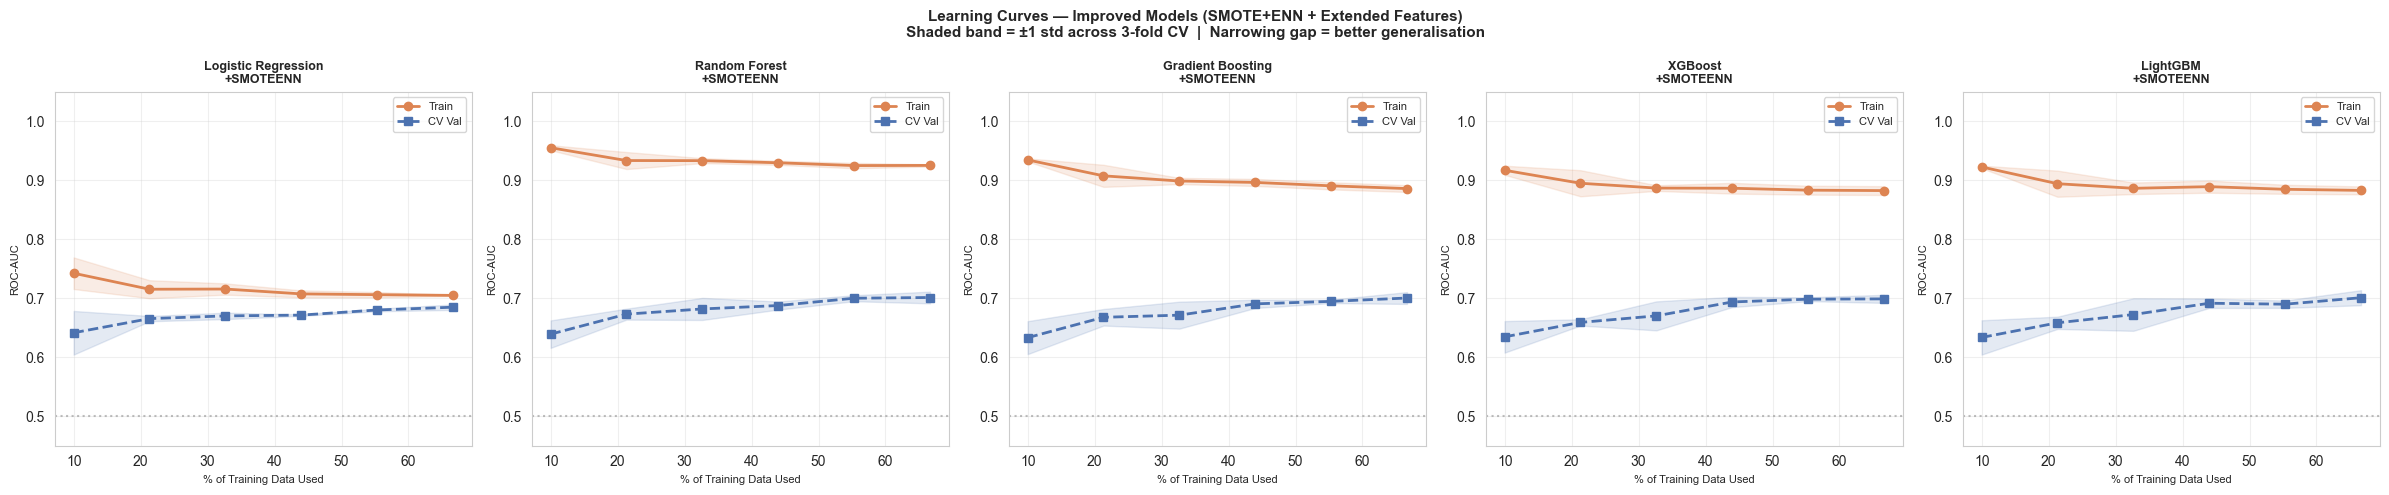


Saved: learning_curves_smoteenn.png


In [42]:

from sklearn.model_selection import learning_curve as sk_learning_curve
from sklearn.base import clone

# ── Learning curves for all 5 improved models ─────────────────────────────
# learning_curve clones the pipeline, so SMOTE+ENN is applied correctly within
# each training fold only — test fold is never resampled.

fig, axes = plt.subplots(1, 5, figsize=(24, 5))
train_sizes_frac = np.linspace(0.15, 1.0, 6)

for ax, (name, pipe) in zip(axes, imp_trained_pipelines.items()):
    print(f'Learning curve: {name}...', flush=True)
    train_sizes, train_scores, val_scores = sk_learning_curve(
        clone(pipe), X_train, y_train,
        train_sizes=train_sizes_frac,
        cv=3, scoring='roc_auc',
        n_jobs=-1, shuffle=True, random_state=RANDOM_STATE
    )
    sizes_pct  = train_sizes / len(X_train) * 100
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(sizes_pct, train_mean, 'o-',  color='#DD8452', label='Train',   linewidth=2)
    ax.fill_between(sizes_pct, train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color='#DD8452')
    ax.plot(sizes_pct, val_mean,   's--', color='#4C72B0', label='CV Val',  linewidth=2)
    ax.fill_between(sizes_pct, val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color='#4C72B0')

    ax.set_title(name.replace(' + SMOTEENN', '\n+SMOTEENN'), fontweight='bold', fontsize=9)
    ax.set_xlabel('% of Training Data Used', fontsize=8)
    ax.set_ylabel('ROC-AUC', fontsize=8)
    ax.set_ylim(0.45, 1.05)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)

plt.suptitle(
    'Learning Curves — Improved Models (SMOTE+ENN + Extended Features)\n'
    'Shaded band = ±1 std across 3-fold CV  |  Narrowing gap = better generalisation',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('smoteenn_outputs/images/learning_curves_smoteenn.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved: learning_curves_smoteenn.png')

### 5b. Per-Stage / Epoch Curves — Model-Specific

| Model | Approach |
|---|---|
| **Gradient Boosting** | `staged_predict_proba` → ROC-AUC per boosting stage (1 → 300) |
| **XGBoost / LightGBM** | Retrain with `eval_set` → log-loss per stage tracked natively |
| **Random Forest** | Retrain with increasing `n_estimators` → shows tree-count saturation |
| **Logistic Regression** | Retrain with increasing `max_iter` → convergence per epoch |

GB staged curve...
XGBoost staged curve...
LightGBM staged curve...
Random Forest tree-count curve...
Logistic Regression epoch curve...


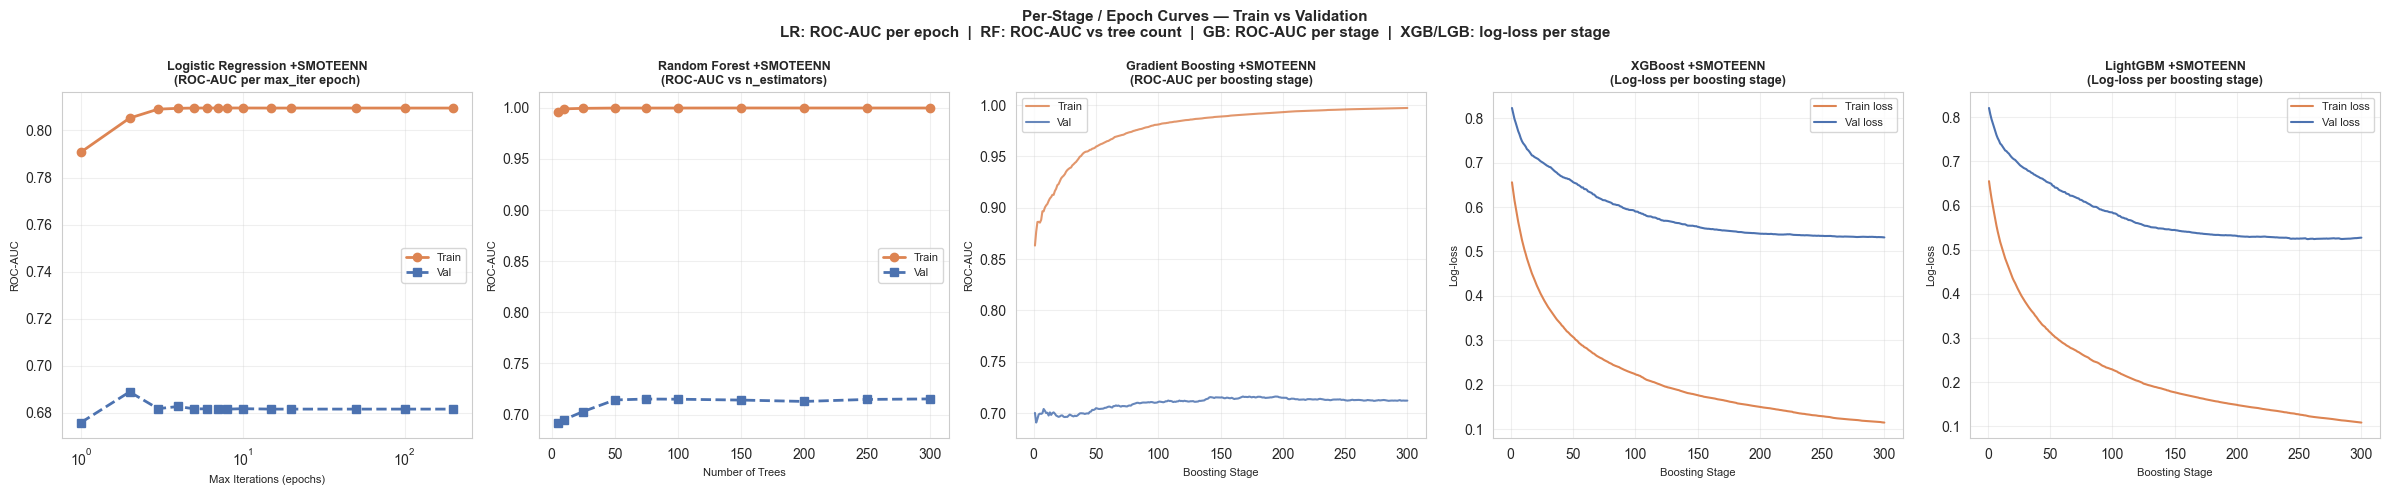


Saved: stage_epoch_curves_smoteenn.png


In [43]:

# ── Helper: extract fitted preprocessor + SMOTE+ENN'd training data ──────────
def get_preprocessed_smoteenn(model_name):
    """Return (X_train_res, y_train_res, X_test_prep) using the fitted pipeline's preprocessor."""
    pipe = imp_trained_pipelines[model_name]
    prep = pipe.named_steps['preprocessor']          # already fitted ColumnTransformer
    X_tr_prep = prep.transform(X_train)
    X_te_prep = prep.transform(X_test)
    smoteenn_tmp = SMOTEENN(random_state=RANDOM_STATE)
    X_tr_res, y_tr_res = smoteenn_tmp.fit_resample(X_tr_prep, y_train)
    return X_tr_res, y_tr_res, X_te_prep

fig, axes = plt.subplots(1, 5, figsize=(24, 5))

# ── 1. Gradient Boosting: staged_predict_proba ────────────────────────────
print('GB staged curve...', flush=True)
X_tr_res, y_tr_res, X_te_prep = get_preprocessed_smoteenn('Gradient Boosting + SMOTEENN')
clf_gb = imp_trained_pipelines['Gradient Boosting + SMOTEENN'].named_steps['classifier']

gb_train, gb_val = [], []
for proba in clf_gb.staged_predict_proba(X_tr_res):
    gb_train.append(roc_auc_score(y_tr_res, proba[:, 1]))
for proba in clf_gb.staged_predict_proba(X_te_prep):
    gb_val.append(roc_auc_score(y_test, proba[:, 1]))

stages = np.arange(1, len(gb_train) + 1)
ax = axes[2]
ax.plot(stages, gb_train, color='#DD8452', linewidth=1.5, label='Train', alpha=0.85)
ax.plot(stages, gb_val,   color='#4C72B0', linewidth=1.5, label='Val',   alpha=0.85)
ax.set_title('Gradient Boosting +SMOTEENN\n(ROC-AUC per boosting stage)', fontweight='bold', fontsize=9)
ax.set_xlabel('Boosting Stage', fontsize=8)
ax.set_ylabel('ROC-AUC', fontsize=8)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── 2. XGBoost: eval_set → log-loss per stage ─────────────────────────────
print('XGBoost staged curve...', flush=True)
X_tr_res, y_tr_res, X_te_prep = get_preprocessed_smoteenn('XGBoost + SMOTEENN')
xgb_stage = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1, verbosity=0
)
xgb_stage.fit(X_tr_res, y_tr_res,
               eval_set=[(X_tr_res, y_tr_res), (X_te_prep, y_test)],
               verbose=False)
xgb_res    = xgb_stage.evals_result_
xgb_stages = np.arange(1, len(xgb_res['validation_0']['logloss']) + 1)

ax = axes[3]
ax.plot(xgb_stages, xgb_res['validation_0']['logloss'], color='#DD8452', linewidth=1.5, label='Train loss')
ax.plot(xgb_stages, xgb_res['validation_1']['logloss'], color='#4C72B0', linewidth=1.5, label='Val loss')
ax.set_title('XGBoost +SMOTEENN\n(Log-loss per boosting stage)', fontweight='bold', fontsize=9)
ax.set_xlabel('Boosting Stage', fontsize=8)
ax.set_ylabel('Log-loss', fontsize=8)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── 3. LightGBM: eval_set → log-loss per stage ────────────────────────────
print('LightGBM staged curve...', flush=True)
X_tr_res, y_tr_res, X_te_prep = get_preprocessed_smoteenn('LightGBM + SMOTEENN')
lgb_stage = LGBMClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)

import lightgbm as lgb_lib
lgb_stage.fit(X_tr_res, y_tr_res,
               eval_set=[(X_tr_res, y_tr_res), (X_te_prep, y_test)],
               eval_metric='binary_logloss',
               callbacks=[lgb_lib.record_evaluation(evals_result := {})])
lgb_stages = np.arange(1, 301)

ax = axes[4]
ax.plot(lgb_stages, list(evals_result['training']['binary_logloss']),    color='#DD8452', linewidth=1.5, label='Train loss')
ax.plot(lgb_stages, list(evals_result['valid_1']['binary_logloss']),     color='#4C72B0', linewidth=1.5, label='Val loss')
ax.set_title('LightGBM +SMOTEENN\n(Log-loss per boosting stage)', fontweight='bold', fontsize=9)
ax.set_xlabel('Boosting Stage', fontsize=8)
ax.set_ylabel('Log-loss', fontsize=8)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── 4. Random Forest: ROC-AUC vs n_estimators ────────────────────────────
print('Random Forest tree-count curve...', flush=True)
X_tr_res, y_tr_res, X_te_prep = get_preprocessed_smoteenn('Random Forest + SMOTEENN')
rf_counts = [5, 10, 25, 50, 75, 100, 150, 200, 250, 300]
rf_train, rf_val = [], []
for n in rf_counts:
    rf_tmp = RandomForestClassifier(n_estimators=n, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1)
    rf_tmp.fit(X_tr_res, y_tr_res)
    rf_train.append(roc_auc_score(y_tr_res,  rf_tmp.predict_proba(X_tr_res)[:, 1]))
    rf_val.append(  roc_auc_score(y_test,    rf_tmp.predict_proba(X_te_prep)[:, 1]))

ax = axes[1]
ax.plot(rf_counts, rf_train, 'o-', color='#DD8452', linewidth=2, label='Train')
ax.plot(rf_counts, rf_val,   's--',color='#4C72B0', linewidth=2, label='Val')
ax.set_title('Random Forest +SMOTEENN\n(ROC-AUC vs n_estimators)', fontweight='bold', fontsize=9)
ax.set_xlabel('Number of Trees', fontsize=8)
ax.set_ylabel('ROC-AUC', fontsize=8)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── 5. Logistic Regression: ROC-AUC per epoch (max_iter) ──────────────────
print('Logistic Regression epoch curve...', flush=True)
X_tr_res, y_tr_res, X_te_prep = get_preprocessed_smoteenn('Logistic Regression + SMOTEENN')
lr_iters = [1, 2, 3, 4, 5, 6, 7, 8, 10, 15, 20, 50, 100, 200]
lr_train, lr_val = [], []
for mi in lr_iters:
    lr_tmp = LogisticRegression(max_iter=mi, random_state=RANDOM_STATE,
                                 class_weight=None, solver='lbfgs')
    lr_tmp.fit(X_tr_res, y_tr_res)
    lr_train.append(roc_auc_score(y_tr_res, lr_tmp.predict_proba(X_tr_res)[:, 1]))
    lr_val.append(  roc_auc_score(y_test,  lr_tmp.predict_proba(X_te_prep)[:, 1]))

ax = axes[0]
ax.plot(lr_iters, lr_train, 'o-', color='#DD8452', linewidth=2, label='Train')
ax.plot(lr_iters, lr_val,   's--',color='#4C72B0', linewidth=2, label='Val')
ax.set_title('Logistic Regression +SMOTEENN\n(ROC-AUC per max_iter epoch)', fontweight='bold', fontsize=9)
ax.set_xlabel('Max Iterations (epochs)', fontsize=8)
ax.set_ylabel('ROC-AUC', fontsize=8)
ax.set_xscale('log')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(
    'Per-Stage / Epoch Curves — Train vs Validation\n'
    'LR: ROC-AUC per epoch  |  RF: ROC-AUC vs tree count  |  GB: ROC-AUC per stage  |  XGB/LGB: log-loss per stage',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('smoteenn_outputs/images/stage_epoch_curves_smoteenn.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved: stage_epoch_curves_smoteenn.png')

### 5c. Results Visualisation

Benchmark bar chart, ROC-AUC/F1 ranking, ROC curves, and confusion matrices for all 5 SMOTE+ENN models.

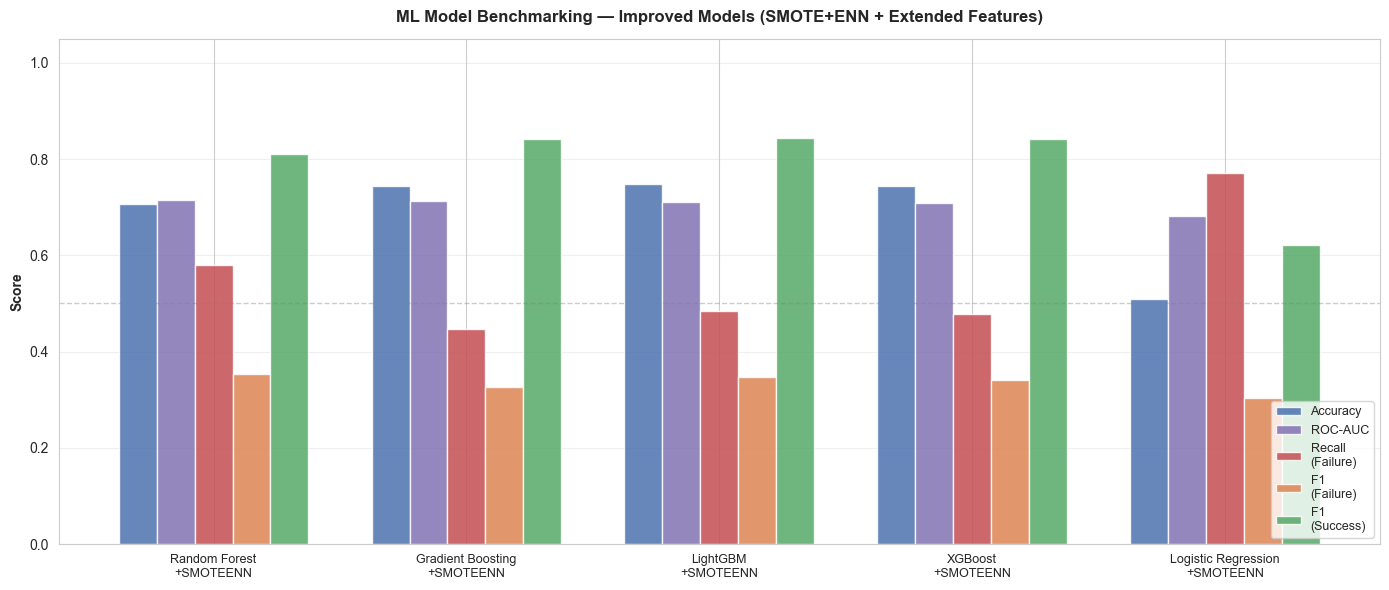

Saved: benchmark_comparison_smoteenn.png


In [44]:

# ── Benchmark comparison bar chart — all 5 SMOTE+ENN models ──────────────
metrics_to_plot  = ['Accuracy', 'ROC-AUC', 'Recall (Failure)', 'F1 (Failure)', 'F1 (Success)']
metric_labels    = ['Accuracy', 'ROC-AUC', 'Recall\n(Failure)', 'F1\n(Failure)', 'F1\n(Success)']
plot_imp = imp_df.set_index('Model')[metrics_to_plot]

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(plot_imp))
width = 0.15
colors_ = ['#4C72B0', '#8172B2', '#C44E52', '#DD8452', '#55A868']

for i, (metric, label, color) in enumerate(zip(metrics_to_plot, metric_labels, colors_)):
    bars_ = ax.bar(x + i * width, plot_imp[metric].values, width,
                   label=label, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + width * 2)
ax.set_xticklabels([n.replace(' + SMOTEENN', '\n+SMOTEENN') for n in plot_imp.index],
                    rotation=0, ha='center', fontsize=9)
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('ML Model Benchmarking — Improved Models (SMOTE+ENN + Extended Features)',
             fontsize=12, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=9)
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4, linewidth=1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('smoteenn_outputs/images/benchmark_comparison_smoteenn.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: benchmark_comparison_smoteenn.png')

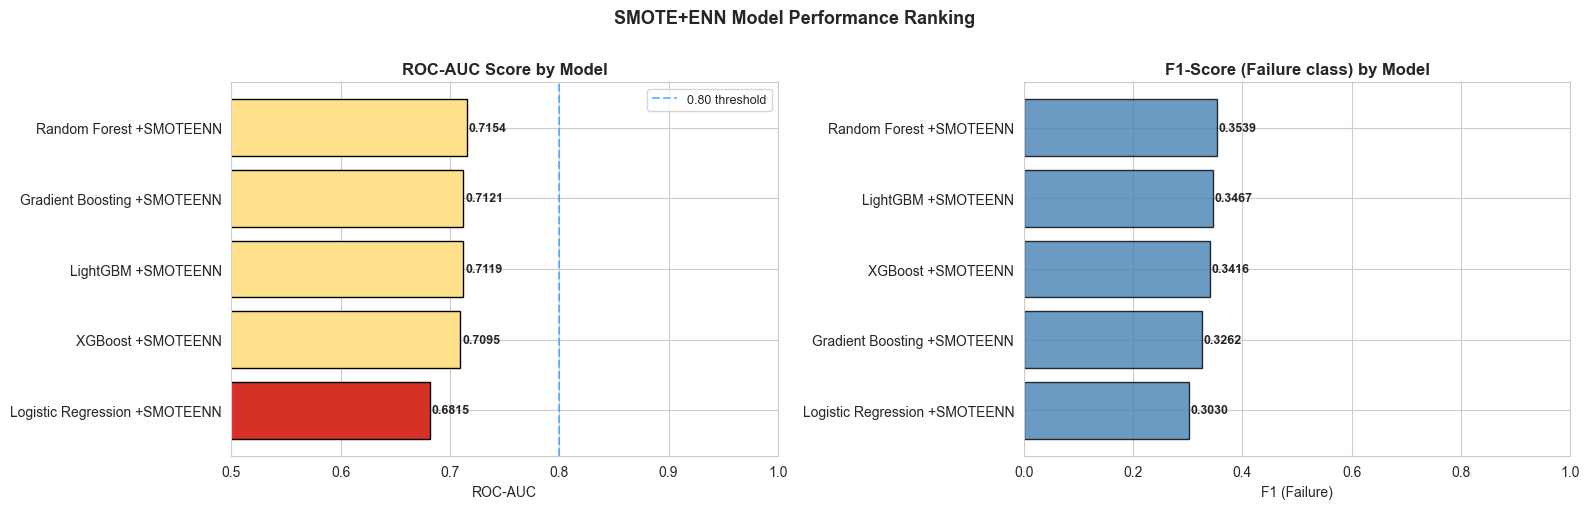

Saved: model_ranking_smoteenn.png


In [45]:

# ── ROC-AUC & F1 (Failure) ranking ────────────────────────────────────────
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sorted_roc = imp_df.sort_values('ROC-AUC', ascending=True)
colors_roc = ['#d73027' if v < 0.70 else '#fee08b' if v < 0.80 else '#1a9850'
               for v in sorted_roc['ROC-AUC']]
bars = axes[0].barh([n.replace(' + SMOTEENN', ' +SMOTEENN') for n in sorted_roc['Model']],
                    sorted_roc['ROC-AUC'], color=colors_roc, edgecolor='black')
for bar, val in zip(bars, sorted_roc['ROC-AUC']):
    axes[0].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
axes[0].set_xlim(0.5, 1.0)
axes[0].axvline(0.8, color='dodgerblue', linestyle='--', alpha=0.6, label='0.80 threshold')
axes[0].legend(fontsize=9)
axes[0].set_title('ROC-AUC Score by Model', fontweight='bold')
axes[0].set_xlabel('ROC-AUC')

sorted_f1 = imp_df.sort_values('F1 (Failure)', ascending=True)
bars2 = axes[1].barh([n.replace(' + SMOTEENN', ' +SMOTEENN') for n in sorted_f1['Model']],
                     sorted_f1['F1 (Failure)'], color='steelblue', edgecolor='black', alpha=0.8)
for bar, val in zip(bars2, sorted_f1['F1 (Failure)']):
    axes[1].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
axes[1].set_xlim(0, 1.0)
axes[1].set_title('F1-Score (Failure class) by Model', fontweight='bold')
axes[1].set_xlabel('F1 (Failure)')

plt.suptitle('SMOTE+ENN Model Performance Ranking', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('smoteenn_outputs/images/model_ranking_smoteenn.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_ranking_smoteenn.png')

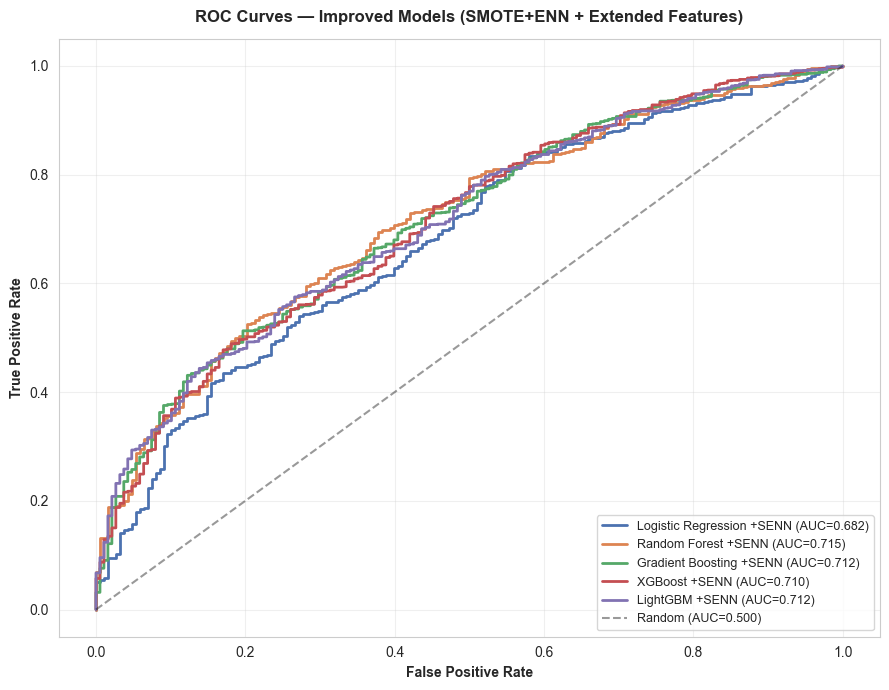

Saved: roc_curves_smoteenn.png


In [46]:

# ── ROC Curves — all 5 SMOTE+ENN models ──────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
colors_roc_lines = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

for (name, pipe), color in zip(imp_trained_pipelines.items(), colors_roc_lines):
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    short = name.replace(' + SMOTEENN', ' +SENN')
    ax.plot(fpr, tpr, label=f'{short} (AUC={auc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.set_title('ROC Curves — Improved Models (SMOTE+ENN + Extended Features)',
             fontsize=12, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('smoteenn_outputs/images/roc_curves_smoteenn.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: roc_curves_smoteenn.png')

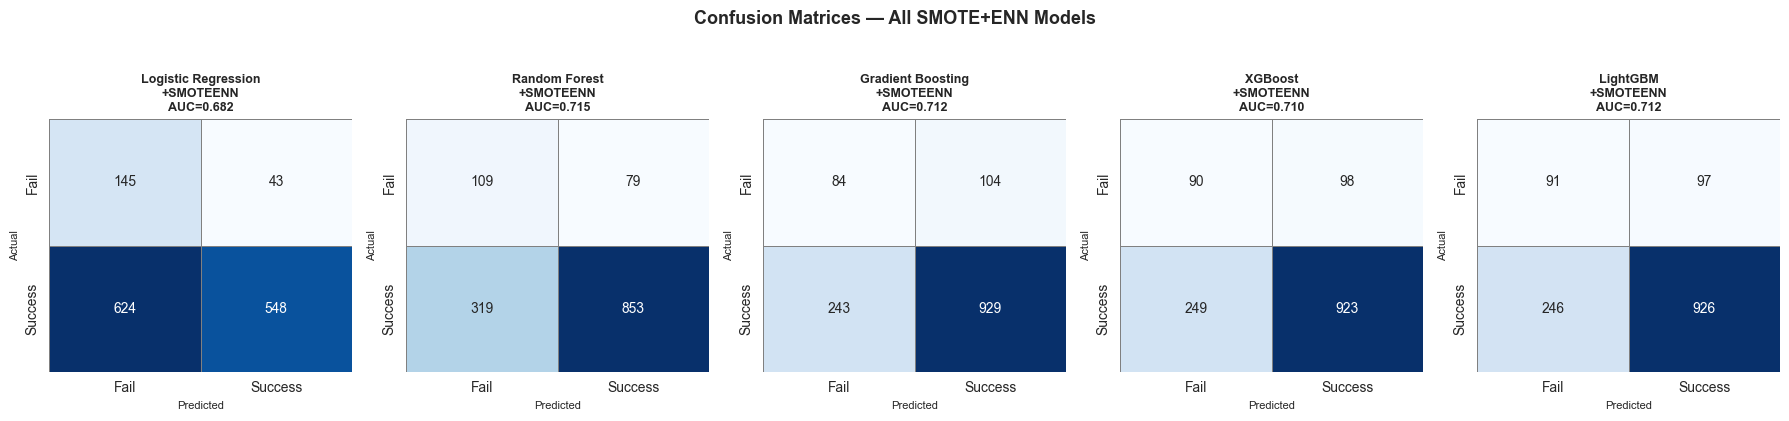

Saved: confusion_matrices_all_smoteenn.png


In [47]:

# ── Confusion matrices grid — all 5 SMOTE+ENN models ─────────────────────
n_imp     = len(imp_trained_pipelines)
fig, axes = plt.subplots(1, n_imp, figsize=(18, 4))

for ax, (name, pipe) in zip(axes, imp_trained_pipelines.items()):
    yp   = pipe.predict(X_test)
    cm_  = confusion_matrix(y_test, yp)
    auc  = roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1])

    sns.heatmap(cm_, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Fail', 'Success'], yticklabels=['Fail', 'Success'],
                linewidths=0.5, linecolor='gray', cbar=False)
    ax.set_title(f'{name.replace(" + SMOTEENN", chr(10)+"+SMOTEENN")}\nAUC={auc:.3f}',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('Actual', fontsize=8)

plt.suptitle('Confusion Matrices — All SMOTE+ENN Models', fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('smoteenn_outputs/images/confusion_matrices_all_smoteenn.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices_all_smoteenn.png')

### 5d. Validation Set Evaluation (10% held-out)

Final unbiased evaluation of all trained models on the 10% validation set — this split was **never used** during training or model selection.


In [49]:

# ── Validation set evaluation — all 5 SMOTE+ENN models ────────────────────
print('=' * 100)
print('  VALIDATION SET EVALUATION  (10% held-out, never seen during training or model selection)')
print('=' * 100)
print(f'  Validation set: {len(X_val):,} records')
print(f'  Failure (0)   : {(y_val==0).sum():,}  ({(y_val==0).mean()*100:.1f}%)')
print(f'  Success (1)   : {(y_val==1).sum():,}  ({(y_val==1).mean()*100:.1f}%)')
print()

val_results = []
for name, pipe in imp_trained_pipelines.items():
    yv_pred  = pipe.predict(X_val)
    yv_proba = pipe.predict_proba(X_val)[:, 1]
    rep_v = classification_report(y_val, yv_pred,
                                   target_names=['Failure', 'Success'],
                                   output_dict=True, zero_division=0)
    val_results.append({
        'Model':                name.replace(' + SMOTEENN', ' +SMOTEENN'),
        'Val Accuracy':         accuracy_score(y_val, yv_pred),
        'Val ROC-AUC':          roc_auc_score(y_val, yv_proba),
        'Val Recall (Failure)': rep_v['Failure']['recall'],
        'Val F1 (Failure)':     rep_v['Failure']['f1-score'],
        'Val F1 (Success)':     rep_v['Success']['f1-score'],
    })

val_df = pd.DataFrame(val_results).sort_values('Val ROC-AUC', ascending=False).reset_index(drop=True)
val_df.index += 1

# Print side-by-side Test vs Val
print(f"  {'Model':<35}  {'Test AUC':>10}  {'Val AUC':>10}  {'ΔAUC':>8}  {'Test Rec(Fail)':>14}  {'Val Rec(Fail)':>14}")
print(f"  {'-'*97}")
for _, vrow in val_df.iterrows():
    model_key = vrow['Model'].replace(' +SMOTEENN', ' + SMOTEENN')
    test_match = imp_df[imp_df['Model'] == model_key]
    if test_match.empty:
        continue
    t_auc = test_match.iloc[0]['ROC-AUC']
    t_rec = test_match.iloc[0]['Recall (Failure)']
    delta = vrow['Val ROC-AUC'] - t_auc
    print(f"  {vrow['Model']:<35}  {t_auc:>10.4f}  {vrow['Val ROC-AUC']:>10.4f}  {delta:>+8.4f}  {t_rec:>14.4f}  {vrow['Val Recall (Failure)']:>14.4f}")

print()
best_val_name = val_df.iloc[0]['Model']
print(f'  Best model on validation set: {best_val_name}')
print(f'  Val ROC-AUC: {val_df.iloc[0]["Val ROC-AUC"]:.4f}')
print(f'  Val Recall (Failure): {val_df.iloc[0]["Val Recall (Failure)"]:.4f}')
print('=' * 100)


  VALIDATION SET EVALUATION  (10% held-out, never seen during training or model selection)
  Validation set: 680 records
  Failure (0)   : 94  (13.8%)
  Success (1)   : 586  (86.2%)

  Model                                  Test AUC     Val AUC      ΔAUC  Test Rec(Fail)   Val Rec(Fail)
  -------------------------------------------------------------------------------------------------
  Random Forest +SMOTEENN                  0.7154      0.7380   +0.0226          0.5798          0.5213
  XGBoost +SMOTEENN                        0.7095      0.7359   +0.0264          0.4787          0.4681
  Gradient Boosting +SMOTEENN              0.7121      0.7326   +0.0205          0.4468          0.4681
  LightGBM +SMOTEENN                       0.7119      0.7287   +0.0168          0.4840          0.4574
  Logistic Regression +SMOTEENN            0.6815      0.7133   +0.0318          0.7713          0.7872

  Best model on validation set: Random Forest +SMOTEENN
  Val ROC-AUC: 0.7380
  Val Recall (

## 6. Baseline vs SMOTE+ENN Comparison

In [ ]:
# ── Load baseline results for comparison ──────────────────────────────────
baseline_df = pd.read_csv('baseline_outputs/ml_benchmark_results.csv')
print(f'Loaded baseline results: {len(baseline_df)} models')
print(baseline_df[['Model', 'ROC-AUC', 'F1-Score']].to_string(index=False))

Loaded baseline results: 12 models
              Model  ROC-AUC  F1-Score
          SVM (RBF) 0.696116  0.758105
           AdaBoost 0.695803  0.925750
Logistic Regression 0.691664  0.743525
  Gradient Boosting 0.688095  0.924791
 MLP Neural Network 0.688002  0.925692
            XGBoost 0.681405  0.786538
           LightGBM 0.678875  0.799237
        Extra Trees 0.672877  0.830258
      Random Forest 0.670574  0.859895
      Decision Tree 0.640551  0.694459
K-Nearest Neighbors 0.628272  0.919135
        Naive Bayes 0.624630  0.907536


In [ ]:

# ── Re-train top-5 baseline models on same split for fair comparison ──────
# (Same data, same split, but baseline features only — no resampling)
from sklearn.linear_model import LogisticRegression as LR
from sklearn.ensemble import RandomForestClassifier as RF, GradientBoostingClassifier as GB

BASELINE_FEATURES = [
    'Age', 'Days_To_Treatment', 'Year', 'Sex', 'Anatomical Site',
    'Registration Group', 'Bacteriologic Status', 'Microscopy Result',
    'Source of Patient', 'Type', 'Province',
]

baseline_preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])

# Use the same df / split indices for fair comparison
X_base = df[BASELINE_FEATURES].copy()
X_base['Age'] = X_base['Age'].fillna(df['Computed_Age'])
X_base_train = X_base.loc[X_train.index]
X_base_test  = X_base.loc[X_test.index]
X_base_val   = X_base.loc[X_val.index]    # new: validation split

BASELINE_MODELS = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=12, random_state=RANDOM_STATE,
        class_weight='balanced', n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        random_state=RANDOM_STATE, subsample=0.8
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        random_state=RANDOM_STATE, eval_metric='logloss',
        scale_pos_weight=(y_train == 0).sum() / y_train.sum(),
        n_jobs=-1, verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        random_state=RANDOM_STATE, class_weight='balanced',
        n_jobs=-1, verbose=-1
    ),
}

baseline_trained = {}
for name, model in BASELINE_MODELS.items():
    pipe = Pipeline(steps=[('preprocessor', baseline_preprocessor), ('classifier', model)])
    pipe.fit(X_base_train, y_train)
    baseline_trained[name] = pipe

print(f'Re-trained {len(BASELINE_MODELS)} baseline models on same data split (70% train) for fair comparison.')
print(f'  X_base_train: {len(X_base_train):,}  |  X_base_test: {len(X_base_test):,}  |  X_base_val: {len(X_base_val):,}')


Re-trained 5 baseline models on same data split for fair comparison.


In [ ]:
# ── Side-by-side comparison ───────────────────────────────────────────────
baseline_lookup = {
    'Logistic Regression + SMOTEENN': 'Logistic Regression',
    'Random Forest + SMOTEENN':       'Random Forest',
    'Gradient Boosting + SMOTEENN':   'Gradient Boosting',
    'XGBoost + SMOTEENN':             'XGBoost',
    'LightGBM + SMOTEENN':            'LightGBM',
}

compare_rows = []
for imp_name, base_name in baseline_lookup.items():
    imp_row = imp_df[imp_df['Model'] == imp_name].iloc[0]

    # Baseline metrics from re-trained models on same split
    base_pipe = baseline_trained[base_name]
    base_pred = base_pipe.predict(X_base_test)
    base_proba = base_pipe.predict_proba(X_base_test)[:, 1]
    base_rep = classification_report(y_test, base_pred,
                                     target_names=['Failure', 'Success'],
                                     output_dict=True, zero_division=0)
    base_auc = roc_auc_score(y_test, base_proba)

    compare_rows.append({
        'Model':                     base_name,
        'Baseline ROC-AUC':          base_auc,
        'SMOTEENN ROC-AUC':          imp_row['ROC-AUC'],
        'ΔAUC':                      imp_row['ROC-AUC'] - base_auc,
        'Baseline Recall (Fail)':    base_rep['Failure']['recall'],
        'SMOTEENN Recall (Fail)':    imp_row['Recall (Failure)'],
        'ΔRecall (Fail)':            imp_row['Recall (Failure)'] - base_rep['Failure']['recall'],
    })

compare_df = pd.DataFrame(compare_rows)

print('Baseline → SMOTE+ENN Comparison (same data split):')
print(compare_df.to_string(index=False, float_format='{:.4f}'.format))

Baseline → SMOTE+ENN Comparison (same data split):
              Model  Baseline ROC-AUC  SMOTEENN ROC-AUC    ΔAUC  Baseline Recall (Fail)  SMOTEENN Recall (Fail)  ΔRecall (Fail)
Logistic Regression            0.6917            0.6882 -0.0035                  0.6543                  0.7660          0.1117
      Random Forest            0.6706            0.7103  0.0397                  0.3085                  0.5638          0.2553
  Gradient Boosting            0.6881            0.7079  0.0198                  0.0479                  0.4628          0.4149
            XGBoost            0.6814            0.7172  0.0357                  0.5213                  0.4947         -0.0266
           LightGBM            0.6789            0.7092  0.0303                  0.5372                  0.4521         -0.0851


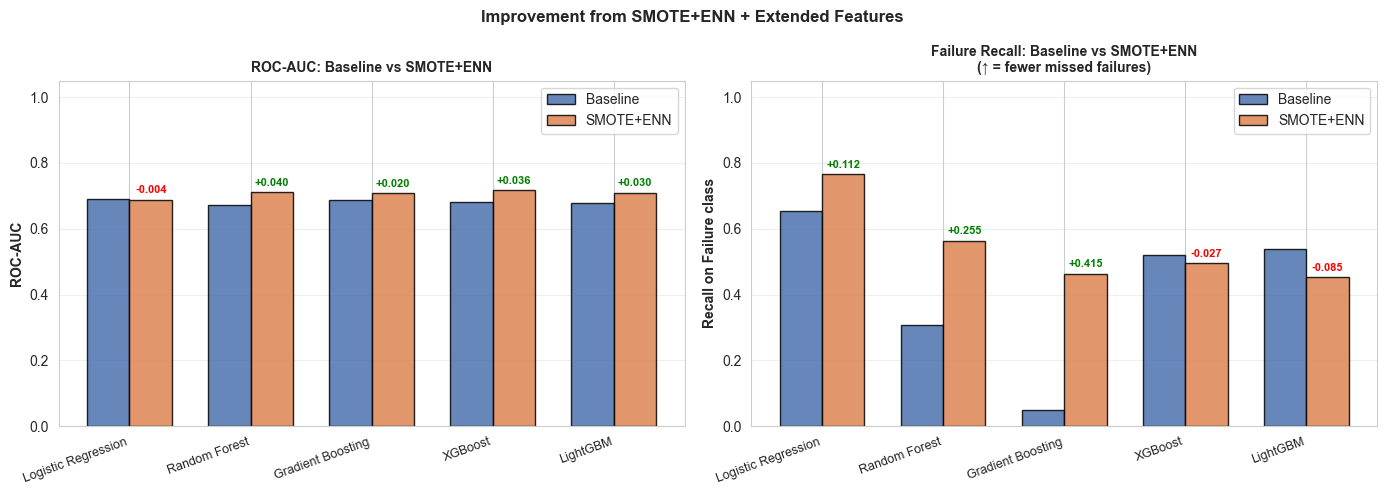

Saved: baseline_vs_smoteenn.png


In [ ]:
# ── Grouped bar chart: Baseline vs SMOTE+ENN ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
model_labels = [r for r in compare_df['Model']]
x = np.arange(len(model_labels))
w = 0.35

for ax, base_col, imp_col, title, ylabel in [
    (axes[0], 'Baseline ROC-AUC', 'SMOTEENN ROC-AUC', 'ROC-AUC: Baseline vs SMOTE+ENN', 'ROC-AUC'),
    (axes[1], 'Baseline Recall (Fail)', 'SMOTEENN Recall (Fail)',
     'Failure Recall: Baseline vs SMOTE+ENN\n(↑ = fewer missed failures)', 'Recall on Failure class'),
]:
    b1 = ax.bar(x - w/2, compare_df[base_col], w, label='Baseline', color='#4C72B0', alpha=0.85, edgecolor='black')
    b2 = ax.bar(x + w/2, compare_df[imp_col],  w, label='SMOTE+ENN', color='#DD8452', alpha=0.85, edgecolor='black')
    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, rotation=20, ha='right', fontsize=9)
    ax.set_ylabel(ylabel, fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)
    # Delta labels
    for xi, (bv, iv) in enumerate(zip(compare_df[base_col], compare_df[imp_col])):
        delta = iv - bv
        color = 'green' if delta > 0 else 'red'
        ax.text(xi + w/2, iv + 0.02, f'{delta:+.3f}', ha='center', fontsize=8,
                color=color, fontweight='bold')

plt.suptitle('Improvement from SMOTE+ENN + Extended Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('smoteenn_outputs/images/baseline_vs_smoteenn.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: baseline_vs_smoteenn.png')

## 7. Best SMOTE+ENN Model — Detailed Analysis

In [ ]:
# ── Best SMOTE+ENN model: detailed report & confusion matrix ──────────────
best_imp_name = imp_df.iloc[0]['Model']
best_imp_pipe = imp_trained_pipelines[best_imp_name]
y_pred_best   = best_imp_pipe.predict(X_test)
y_proba_best  = best_imp_pipe.predict_proba(X_test)[:, 1]

print(f'Best SMOTE+ENN model: {best_imp_name}')
print(f"  ROC-AUC: {roc_auc_score(y_test, y_proba_best):.4f}")
print()
print(classification_report(y_test, y_pred_best,
                             target_names=['Failure (0)', 'Success (1)'], zero_division=0))

Best SMOTE+ENN model: XGBoost + SMOTEENN
  ROC-AUC: 0.7172

              precision    recall  f1-score   support

 Failure (0)       0.26      0.49      0.34       188
 Success (1)       0.91      0.78      0.84      1172

    accuracy                           0.74      1360
   macro avg       0.58      0.64      0.59      1360
weighted avg       0.82      0.74      0.77      1360



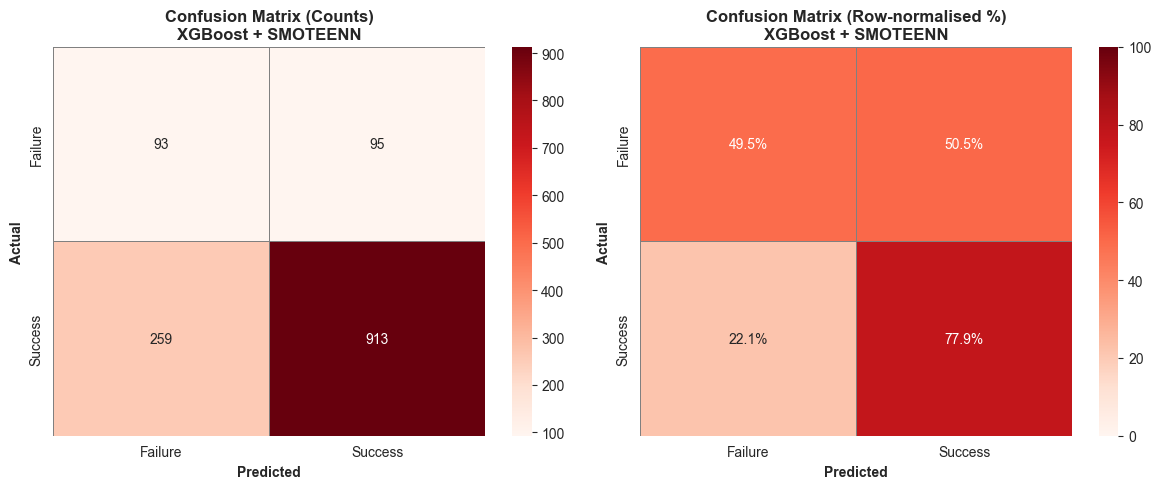

Saved: confusion_matrix_best_smoteenn.png


In [ ]:

# ── Best SMOTE+ENN model — dual confusion matrix (counts + normalised %) ──
cm_best = confusion_matrix(y_test, y_pred_best)
cm_best_pct = cm_best.astype(float) / cm_best.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_best, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['Failure', 'Success'],
            yticklabels=['Failure', 'Success'],
            linewidths=0.5, linecolor='gray')
axes[0].set_xlabel('Predicted', fontweight='bold')
axes[0].set_ylabel('Actual', fontweight='bold')
axes[0].set_title(f'Confusion Matrix (Counts)\n{best_imp_name}', fontweight='bold')

labels_pct = [[f'{v:.1f}%' for v in row] for row in cm_best_pct]
sns.heatmap(cm_best_pct, annot=labels_pct, fmt='', cmap='Reds', ax=axes[1],
            xticklabels=['Failure', 'Success'],
            yticklabels=['Failure', 'Success'],
            linewidths=0.5, linecolor='gray', vmin=0, vmax=100)
axes[1].set_xlabel('Predicted', fontweight='bold')
axes[1].set_ylabel('Actual', fontweight='bold')
axes[1].set_title(f'Confusion Matrix (Row-normalised %)\n{best_imp_name}', fontweight='bold')

plt.tight_layout()
plt.savefig('smoteenn_outputs/images/confusion_matrix_best_smoteenn.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix_best_smoteenn.png')

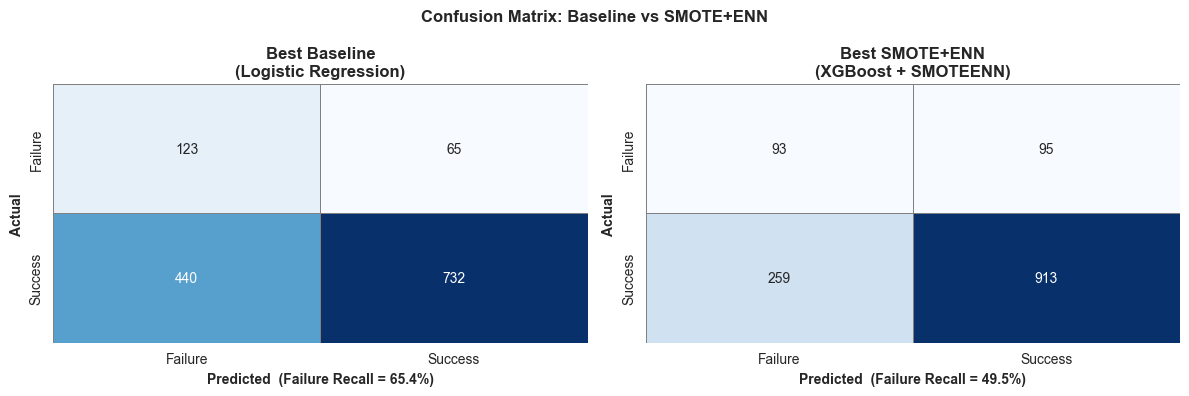

In [ ]:
# ── Confusion matrices: best baseline vs best SMOTE+ENN ───────────────────
best_base_auc = 0
best_base_name = ''
for name, pipe in baseline_trained.items():
    auc = roc_auc_score(y_test, pipe.predict_proba(X_base_test)[:, 1])
    if auc > best_base_auc:
        best_base_auc = auc
        best_base_name = name

best_base_pred = baseline_trained[best_base_name].predict(X_base_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
titles = [
    f'Best Baseline\n({best_base_name})',
    f'Best SMOTE+ENN\n({best_imp_name})',
]
test_sets = [
    (y_test, best_base_pred),
    (y_test, y_pred_best),
]

for ax, (yt, yp), title in zip(axes, test_sets, titles):
    cm_ = confusion_matrix(yt, yp)
    sns.heatmap(cm_, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Failure', 'Success'],
                yticklabels=['Failure', 'Success'],
                linewidths=0.5, linecolor='gray', cbar=False)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Actual', fontweight='bold')
    tn, fp, fn, tp = cm_.ravel()
    fail_recall = tn / (tn + fp) if (tn + fp) > 0 else 0
    ax.set_xlabel(f'Predicted  (Failure Recall = {fail_recall:.1%})', fontweight='bold')

plt.suptitle('Confusion Matrix: Baseline vs SMOTE+ENN', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('smoteenn_outputs/images/cm_baseline_vs_smoteenn.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Feature Importance

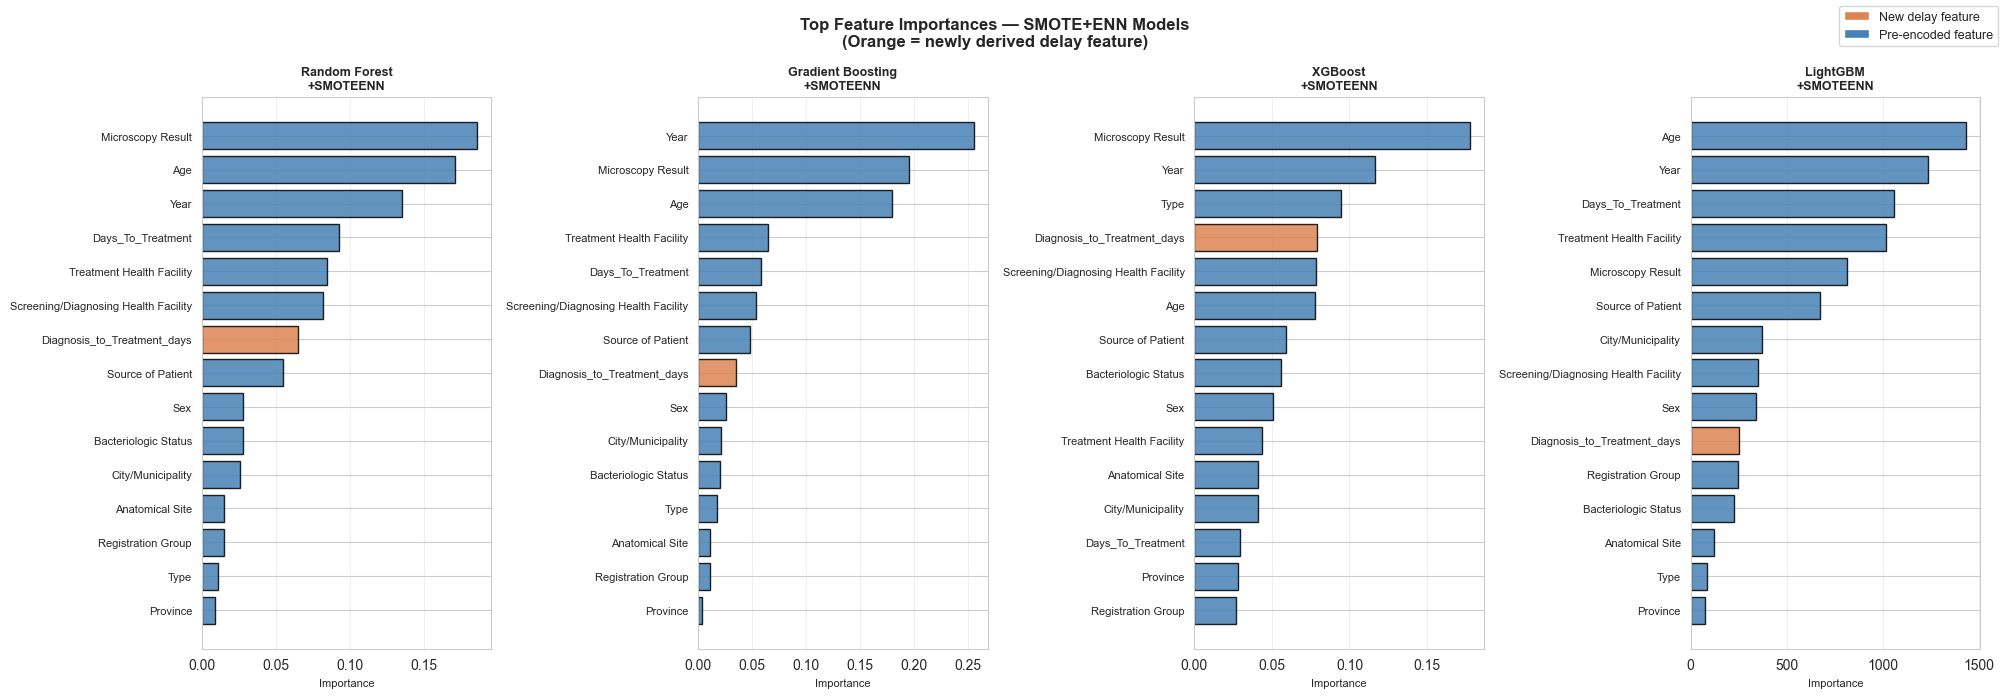

Saved: feature_importance_smoteenn.png


In [ ]:
# ── Feature importance of SMOTE+ENN tree models ────────────────────────────
tree_imp_models = {k: v for k, v in imp_trained_pipelines.items()
                   if any(m in k for m in ['Random Forest', 'Gradient Boosting', 'XGBoost', 'LightGBM'])}

def get_imp_feature_names(pipe):
    return PRE_ENCODED_FEATURES + DERIVED_FEATURES

fig, axes = plt.subplots(1, len(tree_imp_models), figsize=(20, 7))

for ax, (name, pipe) in zip(axes, tree_imp_models.items()):
    clf         = pipe.named_steps['classifier']
    feat_names  = get_imp_feature_names(pipe)
    importances = clf.feature_importances_

    top_n = min(15, len(feat_names))
    top_idx  = np.argsort(importances)[-top_n:]
    top_names = [feat_names[i] for i in top_idx]
    top_vals  = importances[top_idx]

    # Highlight the new delay feature in orange
    delay_feats = {'Diagnosis_to_Treatment_days'}
    colors_ = ['#DD8452' if n in delay_feats else 'steelblue' for n in top_names]

    ax.barh(range(top_n), top_vals, color=colors_, edgecolor='black', alpha=0.85)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_names, fontsize=8)
    ax.set_title(name.replace(' + SMOTEENN', '\n+SMOTEENN'), fontweight='bold', fontsize=9)
    ax.set_xlabel('Importance', fontsize=8)
    ax.grid(axis='x', alpha=0.3)

# Legend
legend_elements = [Patch(facecolor='#DD8452', label='New delay feature'),
                   Patch(facecolor='steelblue', label='Pre-encoded feature')]
fig.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.suptitle('Top Feature Importances — SMOTE+ENN Models\n(Orange = newly derived delay feature)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('smoteenn_outputs/images/feature_importance_smoteenn.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_importance_smoteenn.png')

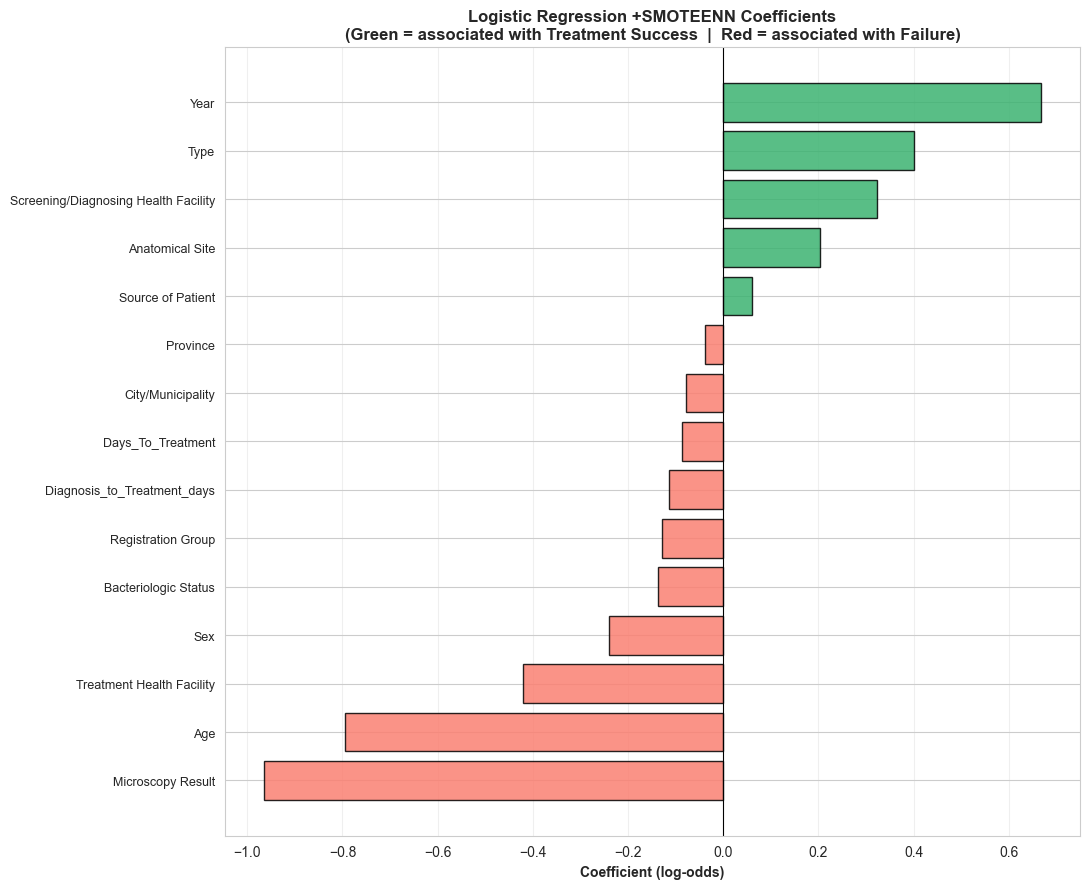

Saved: logreg_coefficients_smoteenn.png


In [ ]:

# ── Logistic Regression +SMOTEENN coefficients ─────────────────────────────
lr_imp_pipe = imp_trained_pipelines['Logistic Regression + SMOTEENN']
lr_imp_clf  = lr_imp_pipe.named_steps['classifier']
feat_names_lr = PRE_ENCODED_FEATURES + DERIVED_FEATURES

coefs_lr   = lr_imp_clf.coef_[0]
sorted_lr  = np.argsort(coefs_lr)
x_vals_lr  = coefs_lr[sorted_lr]
x_names_lr = [feat_names_lr[i] for i in sorted_lr]
colors_lr  = ['salmon' if v < 0 else 'mediumseagreen' for v in x_vals_lr]

fig, ax = plt.subplots(figsize=(11, 9))
ax.barh(range(len(x_vals_lr)), x_vals_lr, color=colors_lr, edgecolor='black', alpha=0.85)
ax.set_yticks(range(len(x_vals_lr)))
ax.set_yticklabels(x_names_lr, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (log-odds)', fontweight='bold')
ax.set_title(
    'Logistic Regression +SMOTEENN Coefficients\n'
    '(Green = associated with Treatment Success  |  Red = associated with Failure)',
    fontweight='bold'
)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('smoteenn_outputs/images/logreg_coefficients_smoteenn.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: logreg_coefficients_smoteenn.png')

## 9. Cross-Validation — SMOTE+ENN Models

5-fold stratified CV on the training set using the same ImbPipeline (SMOTE+ENN applied inside each fold).

In [ ]:

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.base import clone

# ── 5-fold stratified CV — all 5 SMOTE+ENN models ─────────────────────────
# SMOTE+ENN is inside the ImbPipeline so it is applied only on training folds.
cv_imp = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_imp_results = []

for name, pipe in imp_trained_pipelines.items():
    print(f'CV: {name}...', end=' ', flush=True)
    scores = cross_validate(
        clone(pipe), X_train, y_train, cv=cv_imp,
        scoring=['accuracy', 'f1', 'roc_auc', 'recall', 'precision'],
        n_jobs=-1
    )
    cv_imp_results.append({
        'Model':        name.replace(' + SMOTEENN', ' +SMOTEENN'),
        'CV Accuracy':  f"{scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}",
        'CV F1':        f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
        'CV ROC-AUC':   f"{scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}",
        'CV Recall':    f"{scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}",
        'CV Precision': f"{scores['test_precision'].mean():.4f} ± {scores['test_precision'].std():.4f}",
    })
    print('done')

cv_imp_df = pd.DataFrame(cv_imp_results)
print('\n5-Fold Stratified Cross-Validation Results (SMOTE+ENN Models):')
print(cv_imp_df.to_string(index=False))

CV: Logistic Regression + SMOTEENN... done
CV: Random Forest + SMOTEENN... done
CV: Gradient Boosting + SMOTEENN... done
CV: XGBoost + SMOTEENN... done
CV: LightGBM + SMOTEENN... done

5-Fold Stratified Cross-Validation Results (SMOTE+ENN Models):
                        Model     CV Accuracy           CV F1      CV ROC-AUC       CV Recall    CV Precision
Logistic Regression +SMOTEENN 0.5455 ± 0.0091 0.6601 ± 0.0072 0.6918 ± 0.0219 0.5120 ± 0.0066 0.9288 ± 0.0089
      Random Forest +SMOTEENN 0.7169 ± 0.0157 0.8186 ± 0.0107 0.7176 ± 0.0193 0.7411 ± 0.0124 0.9142 ± 0.0092
  Gradient Boosting +SMOTEENN 0.7574 ± 0.0158 0.8501 ± 0.0108 0.7179 ± 0.0199 0.7983 ± 0.0156 0.9091 ± 0.0067
            XGBoost +SMOTEENN 0.7423 ± 0.0229 0.8395 ± 0.0158 0.7118 ± 0.0200 0.7825 ± 0.0224 0.9055 ± 0.0076
           LightGBM +SMOTEENN 0.7543 ± 0.0180 0.8483 ± 0.0128 0.7140 ± 0.0188 0.7981 ± 0.0210 0.9056 ± 0.0057


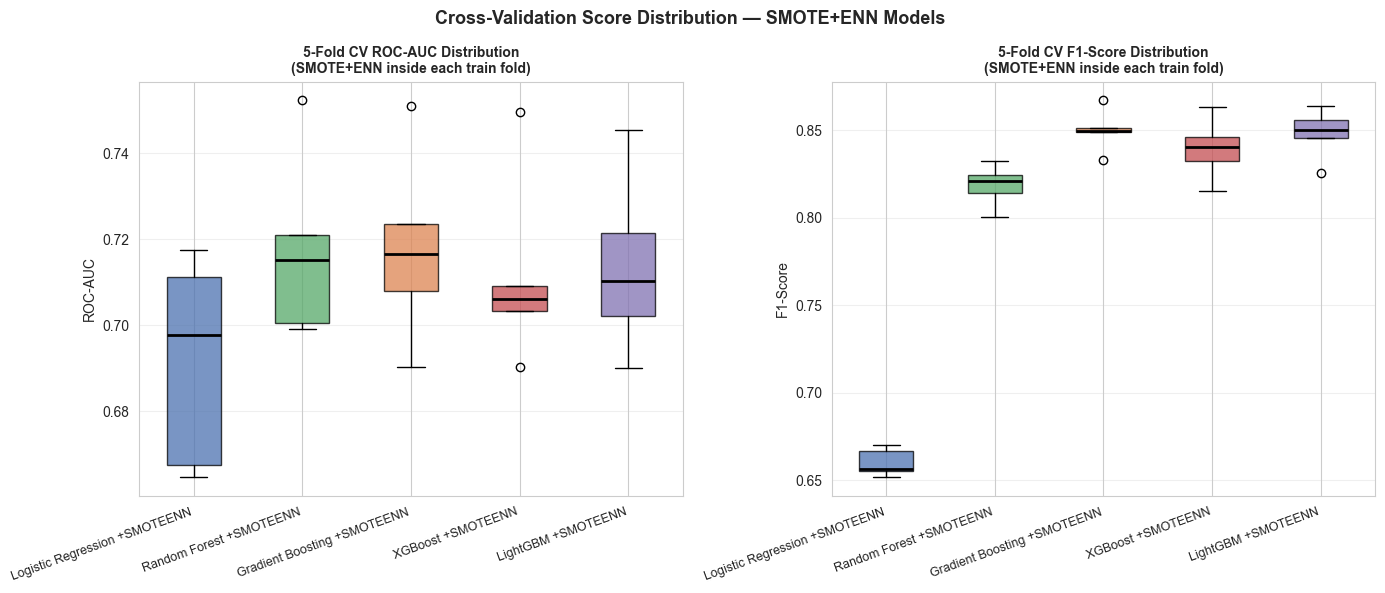

Saved: cv_boxplots_smoteenn.png


In [ ]:

# ── CV ROC-AUC & F1 boxplots ──────────────────────────────────────────────
cv_box_imp = {}
for name, pipe in imp_trained_pipelines.items():
    scores = cross_validate(clone(pipe), X_train, y_train, cv=cv_imp,
                            scoring=['roc_auc', 'f1'], n_jobs=-1)
    cv_box_imp[name.replace(' + SMOTEENN', ' +SMOTEENN')] = {
        'roc_auc': scores['test_roc_auc'],
        'f1':      scores['test_f1'],
    }

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors_box_imp = ['#4C72B0', '#55A868', '#DD8452', '#C44E52', '#8172B2']

for ax, metric, title in zip(axes, ['roc_auc', 'f1'], ['ROC-AUC', 'F1-Score']):
    box_vals = [cv_box_imp[n][metric] for n in cv_box_imp]
    bp = ax.boxplot(box_vals, labels=list(cv_box_imp.keys()), patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], colors_box_imp):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_xticklabels(list(cv_box_imp.keys()), rotation=20, ha='right', fontsize=9)
    ax.set_title(f'5-Fold CV {title} Distribution\n(SMOTE+ENN inside each train fold)',
                 fontweight='bold', fontsize=10)
    ax.set_ylabel(title)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Cross-Validation Score Distribution — SMOTE+ENN Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('smoteenn_outputs/images/cv_boxplots_smoteenn.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cv_boxplots_smoteenn.png')

## 10. Save Results

In [ ]:
# ── Save best SMOTE+ENN model and results ─────────────────────────────────
safe_name = best_imp_name.replace(' ', '_').replace('(', '').replace(')', '').replace('+', 'plus')
joblib.dump(best_imp_pipe, f'smoteenn_outputs/models/smoteenn_best_{safe_name}.pkl')
imp_df.to_csv('smoteenn_outputs/smoteenn_model_results.csv', index=False)
compare_df.to_csv('smoteenn_outputs/baseline_vs_smoteenn_comparison.csv', index=False)
cv_imp_df.to_csv('smoteenn_outputs/cv_smoteenn_results.csv', index=False)

print(f'Saved best SMOTE+ENN model  : smoteenn_outputs/models/smoteenn_best_{safe_name}.pkl')
print(f'Saved SMOTE+ENN results     : smoteenn_outputs/smoteenn_model_results.csv')
print(f'Saved comparison summary    : smoteenn_outputs/baseline_vs_smoteenn_comparison.csv')
print(f'Saved CV results            : smoteenn_outputs/cv_smoteenn_results.csv')

Saved best SMOTE+ENN model  : smoteenn_outputs/models/smoteenn_best_XGBoost_plus_SMOTEENN.pkl
Saved SMOTE+ENN results     : smoteenn_outputs/smoteenn_model_results.csv
Saved comparison summary    : smoteenn_outputs/baseline_vs_smoteenn_comparison.csv
Saved CV results            : smoteenn_outputs/cv_smoteenn_results.csv


## 11. Summary

In [ ]:

# ── Improvement summary ───────────────────────────────────────────────────
print('='*70)
print('  SMOTE+ENN IMPROVEMENT SUMMARY')
print('='*70)
print(f'  Dataset : 2015-2025-ml-ready.csv (pre-encoded & scaled)')
print(f'  Records : {len(df):,} (Success: {y.sum():,} | Failure: {(y==0).sum():,})')
print(f'  Features: {len(IMP_FEATURES)} (baseline {len(IMP_FEATURES)-4} + 3 geographic + 1 derived delay)')
print(f'  Split   : 70% train / 20% test / 10% validation (stratified) + SMOTE+ENN on train set')
print()
print(f'  Best SMOTE+ENN Model: {best_imp_name}')
print(f'  ROC-AUC: {imp_df.iloc[0]["ROC-AUC"]:.4f}')
print()
for _, row in compare_df.iterrows():
    auc_arrow  = '↑' if row['ΔAUC'] > 0 else '↓'
    rec_arrow  = '↑' if row['ΔRecall (Fail)'] > 0 else '↓'
    print(f"  {row['Model']:<25}  "
          f"AUC {row['Baseline ROC-AUC']:.3f}→{row['SMOTEENN ROC-AUC']:.3f} ({auc_arrow}{abs(row['ΔAUC']):.3f})  "
          f"FailRecall {row['Baseline Recall (Fail)']:.3f}→{row['SMOTEENN Recall (Fail)']:.3f} ({rec_arrow}{abs(row['ΔRecall (Fail)']):.3f})")
print('='*70)
print()
print('  Outputs saved to smoteenn_outputs/')
print('    • smoteenn_model_results.csv')
print('    • baseline_vs_smoteenn_comparison.csv')
print('    • cv_smoteenn_results.csv')
print('    • models/smoteenn_best_*.pkl')
print('    • images/*.png')
print('='*70)


  SMOTE+ENN IMPROVEMENT SUMMARY
  Dataset : 2015-2025-ml-ready.csv (pre-encoded & scaled)
  Records : 6,797 (Success: 5,858 | Failure: 939)
  Features: 15 (baseline 11 + 3 geographic + 1 derived delay)
  Split   : 80% train / 20% test (stratified) + SMOTE+ENN on train set

  Best SMOTE+ENN Model: XGBoost + SMOTEENN
  ROC-AUC: 0.7172

  Logistic Regression        AUC 0.692→0.688 (↓0.004)  FailRecall 0.654→0.766 (↑0.112)
  Random Forest              AUC 0.671→0.710 (↑0.040)  FailRecall 0.309→0.564 (↑0.255)
  Gradient Boosting          AUC 0.688→0.708 (↑0.020)  FailRecall 0.048→0.463 (↑0.415)
  XGBoost                    AUC 0.681→0.717 (↑0.036)  FailRecall 0.521→0.495 (↓0.027)
  LightGBM                   AUC 0.679→0.709 (↑0.030)  FailRecall 0.537→0.452 (↓0.085)

  Outputs saved to smoteenn_outputs/
    • smoteenn_model_results.csv
    • baseline_vs_smoteenn_comparison.csv
    • cv_smoteenn_results.csv
    • models/smoteenn_best_*.pkl
    • images/*.png
